# **6. Consistency Analysis**

In [ ]:
# Claude by Anthropic (Opus 4.7) was used as a brainstorming assistant and helping to define the structure
# during the development of this notebook.
# See AI Disclosure Statement submitted with the thesis for details.

## **6.1 Import libraries and define paths**

In [ ]:
from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import shap
from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=UserWarning)

target_column = "extreme_precip_99"
lime_num_samples = 5000
n_repetitions = 10

current_dir = Path.cwd().resolve()
project_dir = current_dir.parent if current_dir.name == "notebooks" else current_dir

processed_dir = project_dir / "data" / "processed"
results_dir   = project_dir / "results"
models_dir    = results_dir / "models"
consistency_dir = results_dir / "consistency"
tables_dir    = consistency_dir / "tables"
figures_dir   = consistency_dir / "figures"

for folder in [consistency_dir, tables_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project directory:        {project_dir}")
print(f"Consistency output dir:   {consistency_dir}")

Project directory:        C:\Users\jensd\Desktop\Data Science\Projects\xai-precipitation-thesis
Consistency output dir:   C:\Users\jensd\Desktop\Data Science\Projects\xai-precipitation-thesis\results\consistency


## **6.2 Load SHAP and LIME explanation results**

In [2]:
dataset_path = processed_dir / "era5_supervised_preprocessed.csv"
model_path = models_dir / "xgboost_best_model.joblib"
features_path = results_dir / "xgboost_best_features.csv"
xai_tables_dir = results_dir / "xai" / "tables"
cases_path = xai_tables_dir / "local_explanation_cases.csv"
local_shap_path = xai_tables_dir / "shap_local_explanations.csv"
local_lime_path = xai_tables_dir / "lime_local_explanations.csv"

model = joblib.load(model_path)
df = pd.read_csv(dataset_path, parse_dates=["valid_time"])
features = pd.read_csv(features_path)["feature"].tolist()

selected_cases = pd.read_csv(cases_path, parse_dates=["valid_time"])
local_shap = pd.read_csv(local_shap_path)
local_lime = pd.read_csv(local_lime_path)

train_df = df[df["split"] == "train"].sort_values("valid_time").reset_index(drop=True)
test_df = df[df["split"] == "test"].sort_values("valid_time").reset_index(drop=True)

X_train = train_df[features].astype(float)
X_test = test_df[features].astype(float)

assert len(selected_cases) == 4
assert set(local_shap["case"]) == set(selected_cases["case"])
assert set(local_lime["case"]) == set(selected_cases["case"])

print(f"Loaded {len(selected_cases)} cases:")
selected_cases[["case", "valid_time", "tp_mm", "predicted_probability"]]

Loaded 4 cases:


,case,valid_time,tp_mm,predicted_probability
0,true_positive,2023-07-27 05:00:00,3.120422,0.985655
1,false_positive,2023-10-20 11:00:00,1.534462,0.985366
2,false_negative,2022-06-19 00:00:00,3.060818,0.949916
3,true_negative,2022-12-17 22:00:00,0.000000,0.004186


## **6.3 Prepare feature importance rankings**

In [3]:
features_by_length = sorted(features, key=len, reverse=True)

def extract_feature_from_rule(rule):
    for feature in features_by_length:
        if feature in rule:
            return feature
    return None


local_lime["feature"] = local_lime["lime_rule"].apply(extract_feature_from_rule)
lime_per_case = local_lime.groupby(["case", "feature"], as_index=False)[
    "abs_lime_weight"
].sum()

shap_rankings = local_shap[["case", "feature", "abs_shap"]].copy()
shap_rankings["shap_rank"] = shap_rankings.groupby("case")["abs_shap"].rank(
    ascending=False, method="min"
)

lime_rankings = lime_per_case.copy()
lime_rankings["lime_rank"] = lime_rankings.groupby("case")["abs_lime_weight"].rank(
    ascending=False, method="min"
)

rankings = shap_rankings.merge(lime_rankings, on=["case", "feature"], how="outer")
rankings.to_csv(tables_dir / "rankings_reference.csv", index=False)

rankings.sort_values(["case", "shap_rank"]).head(20)

,case,feature,abs_shap,shap_rank,abs_lime_weight,lime_rank
22,false_negative,tp_mm_lag1,3.084035,1.0,0.311205,1.0
26,false_negative,tp_mm_roll6_sum,0.315083,2.0,0.048076,2.0
18,false_negative,tcc,0.237633,3.0,0.010776,7.0
6,false_negative,hour_cos,0.136322,4.0,0.011399,4.0
19,false_negative,tcc_lag1,0.128737,5.0,NaN,NaN
28,false_negative,v10,0.105446,6.0,NaN,NaN
5,false_negative,hour,0.088396,7.0,NaN,NaN
0,false_negative,d2m_c,0.046251,8.0,0.010656,8.0
23,false_negative,tp_mm_lag3,0.039352,9.0,0.011283,5.0
25,false_negative,tp_mm_roll24_sum,0.037888,10.0,NaN,NaN


## **6.4 Repeat LIME explanations across random seeds**

In [5]:
def predict_for_lime(rows):
    return model.predict_proba(pd.DataFrame(rows, columns=features))


lime_repetitions = []

for row_id, case in selected_cases.iterrows():
    case_name = case["case"]
    data_row = X_test.iloc[row_id].to_numpy()

    for seed in range(n_repetitions):
        explainer = LimeTabularExplainer(
            training_data=X_train.to_numpy(),
            feature_names=features,
            class_names=["non_extreme", "extreme"],
            mode="classification",
            discretize_continuous=True,
            random_state=seed,
        )

        explanation = explainer.explain_instance(
            data_row=data_row,
            predict_fn=predict_for_lime,
            labels=[1],
            num_features=10,
            num_samples=lime_num_samples,
        )

        for rule, weight in explanation.as_list(label=1):
            lime_repetitions.append(
                {
                    "case": case_name,
                    "seed": seed,
                    "rule": rule,
                    "weight": weight,
                }
            )

lime_repetitions = pd.DataFrame(lime_repetitions)
lime_repetitions["feature"] = lime_repetitions["rule"].apply(extract_feature_from_rule)
lime_repetitions["abs_weight"] = lime_repetitions["weight"].abs()
lime_repetitions.to_csv(tables_dir / "lime_repetitions_raw.csv", index=False)

print(
    f"Generated {len(lime_repetitions):,} rows across {n_repetitions} repetitions per case"
)
lime_repetitions.head(15)

Generated 400 rows across 10 repetitions per case


,case,seed,rule,weight,feature,abs_weight
0,true_positive,0,tp_mm_lag1 <= 0.00,-0.158159,tp_mm_lag1,0.158159
1,true_positive,0,msl_hpa_lag1 > 1021.83,-0.020948,msl_hpa_lag1,0.020948
2,true_positive,0,10.58 < t2m_c <= 15.62,0.019955,t2m_c,0.019955
3,true_positive,0,month_cos > 0.87,-0.019298,month_cos,0.019298
4,true_positive,0,0.83 < tcc <= 1.00,0.016153,tcc,0.016153
5,true_positive,0,msl_hpa_lag6 > 1021.83,-0.015255,msl_hpa_lag6,0.015255
6,true_positive,0,msl_hpa > 1021.83,-0.011661,msl_hpa,0.011661
7,true_positive,0,tcc_roll6_mean > 0.97,-0.010243,tcc_roll6_mean,0.010243
8,true_positive,0,0.00 < hour_sin <= 0.71,-0.008430,hour_sin,0.008430
9,true_positive,0,7.43 < d2m_c <= 11.73,0.006706,d2m_c,0.006706


## **6.5 Measure LIME ranking stability per case**

In [6]:
rep_rankings = lime_repetitions.groupby(["case", "seed", "feature"], as_index=False)[
    "abs_weight"
].sum()
rep_rankings["rank"] = rep_rankings.groupby(["case", "seed"])["abs_weight"].rank(
    ascending=False, method="min"
)

stability_rows = []
for case_name, case_data in rep_rankings.groupby("case"):
    seeds = sorted(case_data["seed"].unique())
    pairwise_rho = []
    pairwise_overlap = []

    for i, seed_a in enumerate(seeds):
        for seed_b in seeds[i + 1 :]:
            a = case_data[case_data["seed"] == seed_a].set_index("feature")["rank"]
            b = case_data[case_data["seed"] == seed_b].set_index("feature")["rank"]
            both = a.index.intersection(b.index)
            if len(both) >= 2:
                pairwise_rho.append(spearmanr(a.loc[both], b.loc[both]).statistic)

            top_a = set(
                case_data[(case_data["seed"] == seed_a) & (case_data["rank"] <= 10)][
                    "feature"
                ]
            )
            top_b = set(
                case_data[(case_data["seed"] == seed_b) & (case_data["rank"] <= 10)][
                    "feature"
                ]
            )
            pairwise_overlap.append(len(top_a & top_b))

    stability_rows.append(
        {
            "case": case_name,
            "mean_pairwise_rho": np.mean(pairwise_rho),
            "std_pairwise_rho": np.std(pairwise_rho),
            "mean_top10_overlap": np.mean(pairwise_overlap),
            "std_top10_overlap": np.std(pairwise_overlap),
        }
    )

stability = pd.DataFrame(stability_rows)
stability.to_csv(tables_dir / "lime_stability_per_case.csv", index=False)
stability

,case,mean_pairwise_rho,std_pairwise_rho,mean_top10_overlap,std_top10_overlap
0,false_negative,0.596032,0.262396,5.600000,0.800000
1,false_positive,0.640529,0.227801,5.733333,1.019804
2,true_negative,0.602116,0.266238,5.644444,0.946468
3,true_positive,0.656878,0.216046,5.866667,0.933333


## **6.6 Compare LIME stability to SHAP (which is deterministic)**

In [7]:
shap_explainer = shap.TreeExplainer(model)

case_rows = []
for row_id, case in selected_cases.iterrows():
    case_rows.append((case["case"], row_id))

shap_repetitions = []

for case_name, row_id in case_rows:
    base_input = X_test.iloc[row_id].to_numpy()

    for seed in range(n_repetitions):
        rng = np.random.default_rng(seed)
        noise = (
            rng.normal(0, 1, size=base_input.shape) * X_train.std().to_numpy() * 0.01
        )
        perturbed_input = base_input + noise

        shap_values = shap_explainer.shap_values(perturbed_input.reshape(1, -1))
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        shap_values = np.asarray(shap_values).ravel()

        for feature, value in zip(features, shap_values):
            shap_repetitions.append(
                {
                    "case": case_name,
                    "seed": seed,
                    "feature": feature,
                    "weight": value,
                }
            )

shap_repetitions = pd.DataFrame(shap_repetitions)
shap_repetitions["abs_weight"] = shap_repetitions["weight"].abs()
shap_repetitions["rank"] = shap_repetitions.groupby(["case", "seed"])[
    "abs_weight"
].rank(ascending=False, method="min")
shap_repetitions.to_csv(tables_dir / "shap_repetitions_raw.csv", index=False)

shap_stability_rows = []
for case_name, case_data in shap_repetitions.groupby("case"):
    seeds = sorted(case_data["seed"].unique())
    pairwise_rho = []
    pairwise_overlap = []

    for i, seed_a in enumerate(seeds):
        for seed_b in seeds[i + 1 :]:
            a = case_data[case_data["seed"] == seed_a].set_index("feature")["rank"]
            b = case_data[case_data["seed"] == seed_b].set_index("feature")["rank"]
            pairwise_rho.append(spearmanr(a, b.loc[a.index]).statistic)

            top_a = set(
                case_data[(case_data["seed"] == seed_a) & (case_data["rank"] <= 10)][
                    "feature"
                ]
            )
            top_b = set(
                case_data[(case_data["seed"] == seed_b) & (case_data["rank"] <= 10)][
                    "feature"
                ]
            )
            pairwise_overlap.append(len(top_a & top_b))

    shap_stability_rows.append(
        {
            "case": case_name,
            "mean_pairwise_rho": np.mean(pairwise_rho),
            "std_pairwise_rho": np.std(pairwise_rho),
            "mean_top10_overlap": np.mean(pairwise_overlap),
            "std_top10_overlap": np.std(pairwise_overlap),
        }
    )

shap_stability = pd.DataFrame(shap_stability_rows)
shap_stability.to_csv(tables_dir / "shap_stability_per_case.csv", index=False)
shap_stability

,case,mean_pairwise_rho,std_pairwise_rho,mean_top10_overlap,std_top10_overlap
0,false_negative,0.948779,0.025270,8.266667,0.646357
1,false_positive,0.985692,0.008285,9.133333,0.653197
2,true_negative,0.974141,0.011979,8.933333,0.679869
3,true_positive,0.984056,0.011441,9.222222,0.553329


## **6.7 Visualize stability across cases**

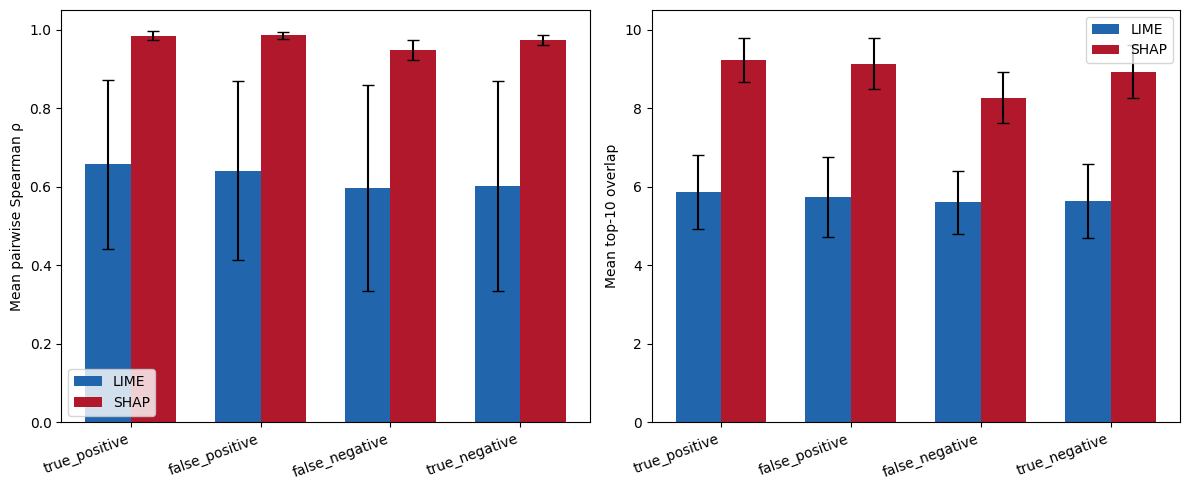

,case,mean_pairwise_rho,std_pairwise_rho,mean_top10_overlap,std_top10_overlap,method
3,true_positive,0.656878,0.216046,5.866667,0.933333,LIME
1,false_positive,0.640529,0.227801,5.733333,1.019804,LIME
0,false_negative,0.596032,0.262396,5.600000,0.800000,LIME
2,true_negative,0.602116,0.266238,5.644444,0.946468,LIME
7,true_positive,0.984056,0.011441,9.222222,0.553329,SHAP
5,false_positive,0.985692,0.008285,9.133333,0.653197,SHAP
4,false_negative,0.948779,0.025270,8.266667,0.646357,SHAP
6,true_negative,0.974141,0.011979,8.933333,0.679869,SHAP


In [8]:
lime_stability = pd.read_csv(tables_dir / "lime_stability_per_case.csv")
shap_stability_df = pd.read_csv(tables_dir / "shap_stability_per_case.csv")

combined = pd.concat(
    [
        lime_stability.assign(method="LIME"),
        shap_stability_df.assign(method="SHAP"),
    ],
    ignore_index=True,
)
combined.to_csv(tables_dir / "stability_combined.csv", index=False)

cases_order = ["true_positive", "false_positive", "false_negative", "true_negative"]
combined["case"] = pd.Categorical(
    combined["case"], categories=cases_order, ordered=True
)
combined = combined.sort_values(["method", "case"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(cases_order))
width = 0.35

for ax, metric, ylabel, ylim in [
    (axes[0], "mean_pairwise_rho", "Mean pairwise Spearman ρ", (0, 1.05)),
    (axes[1], "mean_top10_overlap", "Mean top-10 overlap", (0, 10.5)),
]:
    lime_values = (
        combined[combined["method"] == "LIME"]
        .set_index("case")
        .loc[cases_order, metric]
    )
    shap_values = (
        combined[combined["method"] == "SHAP"]
        .set_index("case")
        .loc[cases_order, metric]
    )
    lime_err = (
        combined[combined["method"] == "LIME"]
        .set_index("case")
        .loc[cases_order, metric.replace("mean", "std")]
    )
    shap_err = (
        combined[combined["method"] == "SHAP"]
        .set_index("case")
        .loc[cases_order, metric.replace("mean", "std")]
    )

    ax.bar(
        x - width / 2,
        lime_values,
        width,
        yerr=lime_err,
        capsize=4,
        label="LIME",
        color="#2166ac",
    )
    ax.bar(
        x + width / 2,
        shap_values,
        width,
        yerr=shap_err,
        capsize=4,
        label="SHAP",
        color="#b2182b",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(cases_order, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(ylim)
    ax.legend()

plt.tight_layout()
plt.savefig(figures_dir / "stability_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

combined

## **6.8 Summarize consistency findings**

In [9]:
summary = combined.pivot_table(
    index="case",
    columns="method",
    values=["mean_pairwise_rho", "mean_top10_overlap"],
)
summary.columns = [f"{metric}_{method}" for metric, method in summary.columns]
summary = summary.reindex(cases_order)

summary["rho_gap"] = (
    summary["mean_pairwise_rho_SHAP"] - summary["mean_pairwise_rho_LIME"]
)
summary["overlap_gap"] = (
    summary["mean_top10_overlap_SHAP"] - summary["mean_top10_overlap_LIME"]
)

summary = summary.round(3)
summary.to_csv(tables_dir / "consistency_summary.csv")

print("Mean pairwise Spearman ρ (higher = more stable):")
print(
    summary[["mean_pairwise_rho_LIME", "mean_pairwise_rho_SHAP", "rho_gap"]].to_string()
)
print("\nMean top-10 overlap (higher = more stable):")
print(
    summary[
        ["mean_top10_overlap_LIME", "mean_top10_overlap_SHAP", "overlap_gap"]
    ].to_string()
)

summary

Mean pairwise Spearman ρ (higher = more stable):
                mean_pairwise_rho_LIME  mean_pairwise_rho_SHAP  rho_gap
case                                                                   
true_positive                    0.657                   0.984    0.327
false_positive                   0.641                   0.986    0.345
false_negative                   0.596                   0.949    0.353
true_negative                    0.602                   0.974    0.372

Mean top-10 overlap (higher = more stable):
                mean_top10_overlap_LIME  mean_top10_overlap_SHAP  overlap_gap
case                                                                         
true_positive                     5.867                    9.222        3.356
false_positive                    5.733                    9.133        3.400
false_negative                    5.600                    8.267        2.667
true_negative                     5.644                    8.933        3.289


C:\Users\jensd\AppData\Local\Temp\ipykernel_26244\3704554866.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  summary = combined.pivot_table(


,mean_pairwise_rho_LIME,mean_pairwise_rho_SHAP,mean_top10_overlap_LIME,mean_top10_overlap_SHAP,rho_gap,overlap_gap
case,,,,,,
true_positive,0.657,0.984,5.867,9.222,0.327,3.356
false_positive,0.641,0.986,5.733,9.133,0.345,3.400
false_negative,0.596,0.949,5.600,8.267,0.353,2.667
true_negative,0.602,0.974,5.644,8.933,0.372,3.289
